In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# Load the match data with pre-match Elo ratings (saved in Phase 1)
matches = pd.read_csv("../data/processed/matches_with_elo.csv", parse_dates=["date"])

# Reload Elo helper functions (same as in 01_explore_data)
INITIAL_ELO = 1500
HOME_ADVANTAGE = 65

def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def predict_probabilities(home_elo, away_elo, neutral):
    """Return (P_home, P_draw, P_away) for a single match."""
    home_adj = home_elo + (HOME_ADVANTAGE if not neutral else 0)
    p_home_strict = expected_score(home_adj, away_elo)
    rating_diff = abs(home_adj - away_elo)
    p_draw = 0.28 * np.exp(-rating_diff / 400)
    p_home = p_home_strict * (1 - p_draw)
    p_away = (1 - p_home_strict) * (1 - p_draw)
    return p_home, p_draw, p_away

print(f"Loaded {len(matches):,} matches with pre-match Elo")
print(f"Date range: {matches['date'].min().date()} to {matches['date'].max().date()}")

Loaded 32,260 matches with pre-match Elo
Date range: 1990-01-12 to 2026-06-08


In [2]:
# Use the last 3 years as the backtest set
backtest = matches[matches['date'] >= '2023-01-01'].copy().reset_index(drop=True)
backtest = backtest.dropna(subset=['home_score', 'away_score', 'home_elo_before', 'away_elo_before'])

print(f"Backtest matches (2023-2026): {len(backtest):,}")

# Generate model predictions for each match using pre-match Elo
preds = backtest.apply(
    lambda r: predict_probabilities(r['home_elo_before'], r['away_elo_before'], r['neutral']),
    axis=1
)
backtest[['p_home', 'p_draw', 'p_away']] = pd.DataFrame(preds.tolist(), index=backtest.index)

# Actual outcome (one-hot): 1 if home win, 1 if draw, 1 if away win
backtest['outcome_home'] = (backtest['home_score'] > backtest['away_score']).astype(int)
backtest['outcome_draw'] = (backtest['home_score'] == backtest['away_score']).astype(int)
backtest['outcome_away'] = (backtest['home_score'] < backtest['away_score']).astype(int)

# Sanity check: probabilities sum to 1
print(f"\nProb sums (should all be ~1.0): mean={backtest[['p_home','p_draw','p_away']].sum(axis=1).mean():.4f}")
print(f"\nSample predictions:")
print(backtest[['date','home_team','away_team','p_home','p_draw','p_away',
                'home_score','away_score']].head(10).to_string())

Backtest matches (2023-2026): 3,572

Prob sums (should all be ~1.0): mean=1.0000

Sample predictions:
        date    home_team             away_team    p_home    p_draw    p_away  home_score  away_score
0 2023-01-02     Thailand              Cambodia  0.865007  0.082749  0.052244         3.0         1.0
1 2023-01-02  Philippines             Indonesia  0.289702  0.223495  0.486803         1.0         2.0
2 2023-01-03      Vietnam               Myanmar  0.873467  0.079050  0.047483         3.0         0.0
3 2023-01-03     Malaysia             Singapore  0.568954  0.192100  0.238947         4.0         1.0
4 2023-01-06         Iraq                  Oman  0.451705  0.237900  0.310395         0.0         0.0
5 2023-01-06        Yemen          Saudi Arabia  0.057207  0.086452  0.856341         0.0         2.0
6 2023-01-06    Indonesia               Vietnam  0.324776  0.248761  0.426463         0.0         0.0
7 2023-01-07      Bahrain  United Arab Emirates  0.366908  0.276540  0.356552     

In [3]:
# --- Metric 1: Accuracy (did we predict the right outcome?) ---
predicted_class = backtest[['p_home', 'p_draw', 'p_away']].values.argmax(axis=1)
actual_class = backtest[['outcome_home', 'outcome_draw', 'outcome_away']].values.argmax(axis=1)
accuracy = (predicted_class == actual_class).mean()

# Baseline: always predict home win (most common outcome)
home_win_rate = backtest['outcome_home'].mean()
baseline_accuracy = home_win_rate  # if we always guess "home wins"

# --- Metric 2: Brier Score (sum of squared errors across all 3 outcomes) ---
# Lower is better. Range: 0 (perfect) to 2 (worst). Random guess ≈ 0.667.
brier = ((backtest[['p_home','p_draw','p_away']].values -
          backtest[['outcome_home','outcome_draw','outcome_away']].values) ** 2).sum(axis=1).mean()

# Brier for the trivial "uniform 1/3 each" baseline
uniform_brier = ((np.full((len(backtest), 3), 1/3) -
                  backtest[['outcome_home','outcome_draw','outcome_away']].values) ** 2).sum(axis=1).mean()

# --- Metric 3: Log Loss (penalizes confident wrong predictions hard) ---
# Lower is better. Random 3-class guess = ln(3) ≈ 1.0986
eps = 1e-15  # avoid log(0)
probs = backtest[['p_home','p_draw','p_away']].values.clip(eps, 1-eps)
actuals = backtest[['outcome_home','outcome_draw','outcome_away']].values
log_loss = -(actuals * np.log(probs)).sum(axis=1).mean()
uniform_log_loss = np.log(3)

print("=" * 55)
print("BACKTEST RESULTS (2023-2026, 3572 matches)")
print("=" * 55)
print(f"\nAccuracy:        {accuracy:.1%}   (baseline 'always home': {baseline_accuracy:.1%})")
print(f"Brier Score:     {brier:.4f}  (uniform baseline: {uniform_brier:.4f})")
print(f"Log Loss:        {log_loss:.4f}  (uniform baseline: {uniform_log_loss:.4f})")
print(f"\nOutcome distribution in test set:")
print(f"  Home wins: {backtest['outcome_home'].mean():.1%}")
print(f"  Draws:     {backtest['outcome_draw'].mean():.1%}")
print(f"  Away wins: {backtest['outcome_away'].mean():.1%}")

BACKTEST RESULTS (2023-2026, 3572 matches)

Accuracy:        60.5%   (baseline 'always home': 47.2%)
Brier Score:     0.5155  (uniform baseline: 0.6667)
Log Loss:        0.8824  (uniform baseline: 1.0986)

Outcome distribution in test set:
  Home wins: 47.2%
  Draws:     23.0%
  Away wins: 29.8%


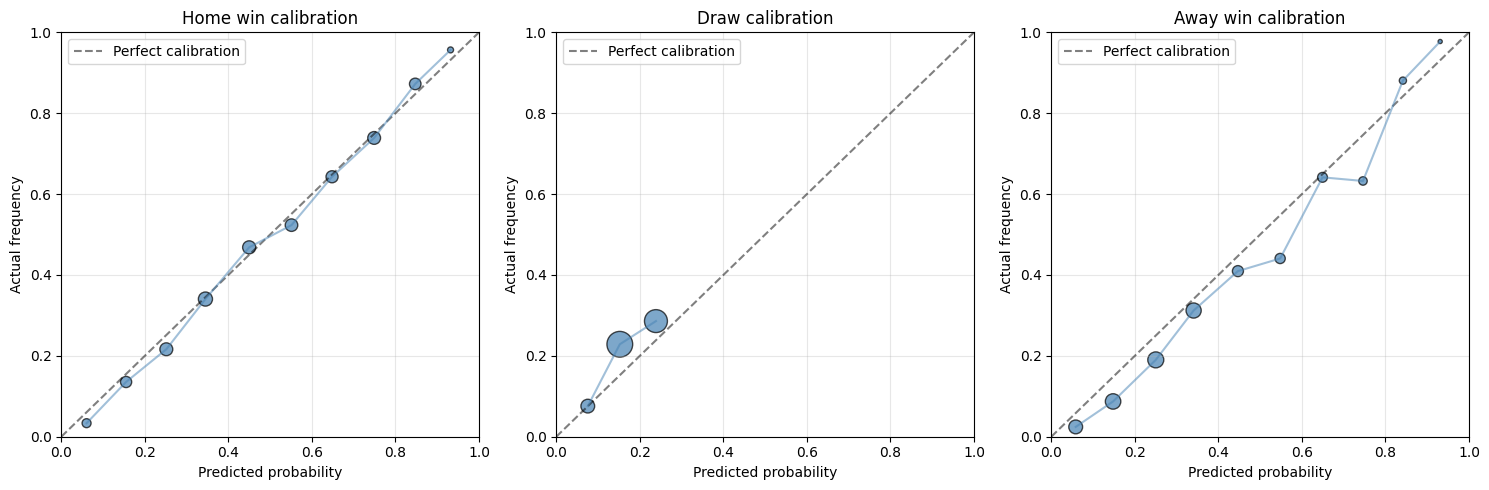

Saved calibration plot to data/processed/calibration.png


In [4]:
# Calibration: bin predictions by probability, then check actual win rate per bin
def calibration_data(probs, actuals, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers, bin_actuals, bin_counts = [], [], []
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() < 20:  # skip near-empty bins
            continue
        bin_centers.append(probs[mask].mean())
        bin_actuals.append(actuals[mask].mean())
        bin_counts.append(mask.sum())
    return np.array(bin_centers), np.array(bin_actuals), np.array(bin_counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels = ['Home win', 'Draw', 'Away win']
prob_cols = ['p_home', 'p_draw', 'p_away']
actual_cols = ['outcome_home', 'outcome_draw', 'outcome_away']

for ax, label, pcol, acol in zip(axes, labels, prob_cols, actual_cols):
    centers, actuals, counts = calibration_data(
        backtest[pcol].values, backtest[acol].values
    )
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.scatter(centers, actuals, s=counts/5, alpha=0.7, color='steelblue', edgecolor='black')
    ax.plot(centers, actuals, '-', color='steelblue', alpha=0.5)
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Actual frequency')
    ax.set_title(f'{label} calibration')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/calibration.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved calibration plot to data/processed/calibration.png")

In [5]:
# Save backtest predictions and metrics for the dashboard / README
backtest.to_csv("../data/processed/backtest_predictions.csv", index=False)

metrics = {
    "n_matches": int(len(backtest)),
    "date_range": [str(backtest['date'].min().date()), str(backtest['date'].max().date())],
    "accuracy": round(float(accuracy), 4),
    "baseline_accuracy_always_home": round(float(baseline_accuracy), 4),
    "brier_score": round(float(brier), 4),
    "brier_uniform_baseline": round(float(uniform_brier), 4),
    "log_loss": round(float(log_loss), 4),
    "log_loss_uniform_baseline": round(float(uniform_log_loss), 4),
}
with open("../data/processed/backtest_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved backtest_predictions.csv and backtest_metrics.json")
print(json.dumps(metrics, indent=2))

Saved backtest_predictions.csv and backtest_metrics.json
{
  "n_matches": 3572,
  "date_range": [
    "2023-01-02",
    "2026-06-08"
  ],
  "accuracy": 0.6047,
  "baseline_accuracy_always_home": 0.4723,
  "brier_score": 0.5155,
  "brier_uniform_baseline": 0.6667,
  "log_loss": 0.8824,
  "log_loss_uniform_baseline": 1.0986
}
